In [6]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.



In [3]:
### Simple implementation
# Prepare qubit 0 in the state to protect
# Encode qubit 0 into 9 qubits using Shor code
# Introduce an error: X, Z, or H
# Correct bit-flip errors inside each block of 3 qubits
# Correct phase-flip errors across the 3 blocks
# Decode the 9 qubits back to qubit 0
# Measure qubit 0 to check whether the original state was recovered

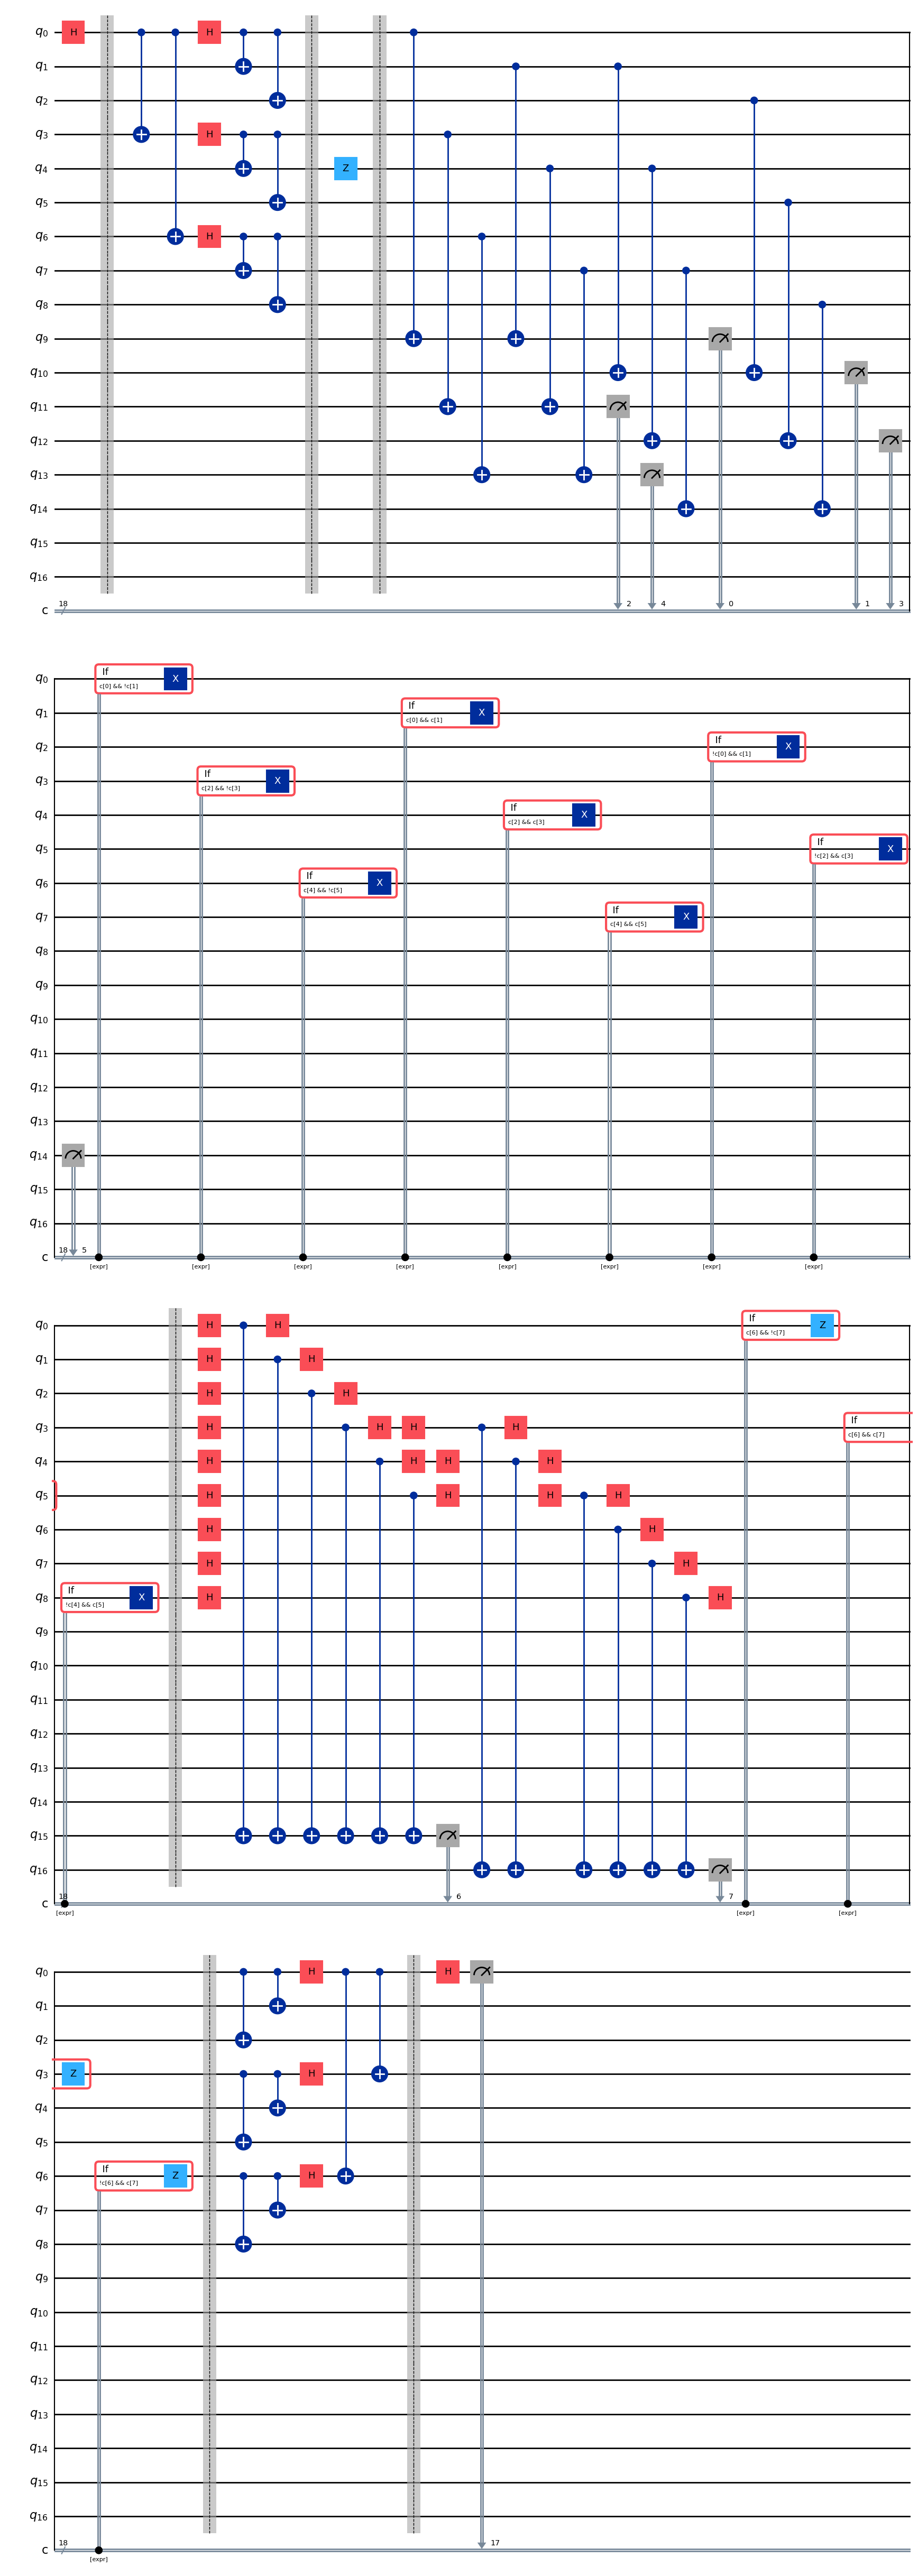

In [4]:
# Shor code

shor = QuantumCircuit(17, 18)

# q0-q8 = encoded data qubits
# q9-q14 = bit-flip syndrome qubits
# q15-q16 = phase-flip syndrome qubits
# c0-c7 = syndrome measurements
# c17 = final measurement result

# Prepare original qubit in |+>
shor.h(0)

shor.barrier()

# -----------------------
# Encode using Shor code
# -----------------------

# Phase-flip repetition across 3 blocks
shor.cx(0, 3)
shor.cx(0, 6)

shor.h(0)
shor.h(3)
shor.h(6)

# Bit-flip repetition inside each block
shor.cx(0, 1)
shor.cx(0, 2)

shor.cx(3, 4)
shor.cx(3, 5)

shor.cx(6, 7)
shor.cx(6, 8)

shor.barrier()

# -----------------------
# Add an error here
# -----------------------

# Try ONE of these at a time:

# Bit-flip error
# shor.x(4)

# Phase-flip error
shor.z(4)

# Try H error
# shor.h(4)

# Try two errors
# shor.x(1)
# shor.x(4)

shor.barrier()

# -----------------------
# Bit-flip correction
# -----------------------

# Block 1: q0 q1 q2, syndrome q9 q10
shor.cx(0, 9)
shor.cx(1, 9)
shor.cx(1, 10)
shor.cx(2, 10)

# Block 2: q3 q4 q5, syndrome q11 q12
shor.cx(3, 11)
shor.cx(4, 11)
shor.cx(4, 12)
shor.cx(5, 12)

# Block 3: q6 q7 q8, syndrome q13 q14
shor.cx(6, 13)
shor.cx(7, 13)
shor.cx(7, 14)
shor.cx(8, 14)

shor.measure([9,10,11,12,13,14], [0,1,2,3,4,5])

# Correct block 1
with shor.if_test(expr.logic_and(shor.clbits[0], expr.logic_not(shor.clbits[1]))):
    shor.x(0)

with shor.if_test(expr.logic_and(shor.clbits[0], shor.clbits[1])):
    shor.x(1)

with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[0]), shor.clbits[1])):
    shor.x(2)

# Correct block 2
with shor.if_test(expr.logic_and(shor.clbits[2], expr.logic_not(shor.clbits[3]))):
    shor.x(3)

with shor.if_test(expr.logic_and(shor.clbits[2], shor.clbits[3])):
    shor.x(4)

with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[2]), shor.clbits[3])):
    shor.x(5)

# Correct block 3
with shor.if_test(expr.logic_and(shor.clbits[4], expr.logic_not(shor.clbits[5]))):
    shor.x(6)

with shor.if_test(expr.logic_and(shor.clbits[4], shor.clbits[5])):
    shor.x(7)

with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[4]), shor.clbits[5])):
    shor.x(8)

shor.barrier()

# -----------------------
# Phase-flip correction
# -----------------------

# Measure phase syndrome by checking blocks in X basis

# First phase syndrome: compare block 1 and block 2
for q in range(0, 6):
    shor.h(q)
    shor.cx(q, 15)
    shor.h(q)

# Second phase syndrome: compare block 2 and block 3
for q in range(3, 9):
    shor.h(q)
    shor.cx(q, 16)
    shor.h(q)

shor.measure([15,16], [6,7])

# Correct phase error
# syndrome 10 means block 1
with shor.if_test(expr.logic_and(shor.clbits[6], expr.logic_not(shor.clbits[7]))):
    shor.z(0)

# syndrome 11 means block 2
with shor.if_test(expr.logic_and(shor.clbits[6], shor.clbits[7])):
    shor.z(3)

# syndrome 01 means block 3
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[6]), shor.clbits[7])):
    shor.z(6)

shor.barrier()

# -----------------------
# Decode back to one qubit
# -----------------------

# Undo bit repetition
for b in [0, 3, 6]:
    shor.cx(b, b+2)
    shor.cx(b, b+1)

# Undo phase repetition
shor.h(0)
shor.h(3)
shor.h(6)

shor.cx(0, 6)
shor.cx(0, 3)

shor.barrier()

# Original state was |+>, so apply H before measuring.
# If correction worked, result should be 0.
shor.h(0)
shor.measure(0, 17)

shor.draw("mpl")

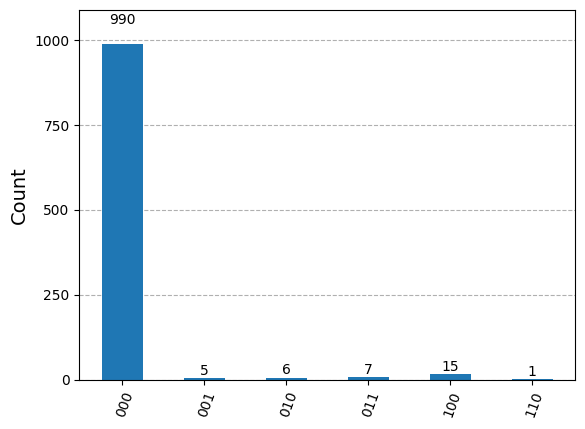

In [8]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=17, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)